<a href="https://colab.research.google.com/github/4501kietgroup-web/Team1/blob/main/Var_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Musical Instrument Frequency Analyzer
# B.Tech Mathematics Mini Project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

# =========================
# USER INPUTS
# =========================

# Number of masses in the guitar-string model
N = 10

# Mass of each small segment (kg)
m = 0.01

# Spring stiffness (N/m)
k = 1000

# Fixed-end string assumption:
# The first and last ends of the string are fixed.

print("Musical Instrument Frequency Analyzer")
print("-------------------------------------")
print("Number of masses (N):", N)
print("Mass of each segment:", m, "kg")
print("Spring stiffness:", k, "N/m")

Musical Instrument Frequency Analyzer
-------------------------------------
Number of masses (N): 10
Mass of each segment: 0.01 kg
Spring stiffness: 1000 N/m


In [ ]:

# =========================
# MATHEMATICAL MODEL
# =========================

# For N masses connected by identical springs,
# the stiffness matrix is tridiagonal.

K = np.zeros((N, N))

for i in range(N):
    K[i, i] = 2 * k

    if i > 0:
        K[i, i - 1] = -k

    if i < N - 1:
        K[i, i + 1] = -k

print("Stiffness Matrix K:")
print(K)

Stiffness Matrix K:
[[ 2000. -1000.     0.     0.     0.     0.     0.     0.     0.     0.]
 [-1000.  2000. -1000.     0.     0.     0.     0.     0.     0.     0.]
 [    0. -1000.  2000. -1000.     0.     0.     0.     0.     0.     0.]
 [    0.     0. -1000.  2000. -1000.     0.     0.     0.     0.     0.]
 [    0.     0.     0. -1000.  2000. -1000.     0.     0.     0.     0.]
 [    0.     0.     0.     0. -1000.  2000. -1000.     0.     0.     0.]
 [    0.     0.     0.     0.     0. -1000.  2000. -1000.     0.     0.]
 [    0.     0.     0.     0.     0.     0. -1000.  2000. -1000.     0.]
 [    0.     0.     0.     0.     0.     0.     0. -1000.  2000. -1000.]
 [    0.     0.     0.     0.     0.     0.     0.     0. -1000.  2000.]]


In [ ]:

# =========================
# EIGENVALUE CALCULATION
# =========================

# Equation:
# K v = lambda M v
#
# Since all masses are equal:
# M = mI
#
# Therefore:
# K v = lambda*m*v
#
# So the eigenvalues of K/m are omega^2.

A = K / m

# eigh is suitable because A is symmetric
eigenvalues, eigenvectors = np.linalg.eigh(A)

# Eigenvalues = angular frequency squared
omega_squared = eigenvalues

# Angular frequency
omega = np.sqrt(omega_squared)

# Convert angular frequency to frequency in Hz
frequency = omega / (2 * np.pi)

print("Eigenvalues (ω²):")
print(omega_squared)

print("\nAngular frequencies (ω):")
print(omega)

print("\nFrequencies (Hz):")
print(frequency)

Eigenvalues (ω²):
[  8101.4052771   31749.29343376  69027.85321094 116916.99739962
 171537.03234534 228462.96765466 283083.00260038 330972.14678906
 368250.70656624 391898.5947229 ]

Angular frequencies (ω):
[ 90.00780676 178.18331413 262.73152306 341.93127584 414.1702939
 477.97799913 532.05545068 575.30178758 606.83663911 626.01804664]

Frequencies (Hz):
[14.32518736 28.35875522 41.8150206  54.42005275 65.91724956 76.07256125
 84.67925498 91.56212326 96.58105076 99.63386659]


In [ ]:

# =========================
# RESULT TABLE
# =========================

results = pd.DataFrame({
    "Mode": np.arange(1, N + 1),
    "Eigenvalue (ω²)": omega_squared,
    "Angular Frequency (rad/s)": omega,
    "Frequency (Hz)": frequency
})

print("Vibration Mode Results")
print("=======================")

display(results.round(3))

Vibration Mode Results


,Mode,Eigenvalue (ω²),Angular Frequency (rad/s),Frequency (Hz)
0,1,8101.405,90.008,14.325
1,2,31749.293,178.183,28.359
2,3,69027.853,262.732,41.815
3,4,116916.997,341.931,54.420
4,5,171537.032,414.170,65.917
5,6,228462.968,477.978,76.073
6,7,283083.003,532.055,84.679
7,8,330972.147,575.302,91.562
8,9,368250.707,606.837,96.581
9,10,391898.595,626.018,99.634


In [ ]:

# =========================
# FIRST 3 HARMONICS
# =========================

print("First 3 Harmonics")
print("=================")

for i in range(3):
    print(
        f"Harmonic {i+1}: "
        f"ω² = {omega_squared[i]:.2f}, "
        f"ω = {omega[i]:.2f} rad/s, "
        f"f = {frequency[i]:.2f} Hz"
    )

First 3 Harmonics
Harmonic 1: ω² = 8101.41, ω = 90.01 rad/s, f = 14.33 Hz
Harmonic 2: ω² = 31749.29, ω = 178.18 rad/s, f = 28.36 Hz
Harmonic 3: ω² = 69027.85, ω = 262.73 rad/s, f = 41.82 Hz


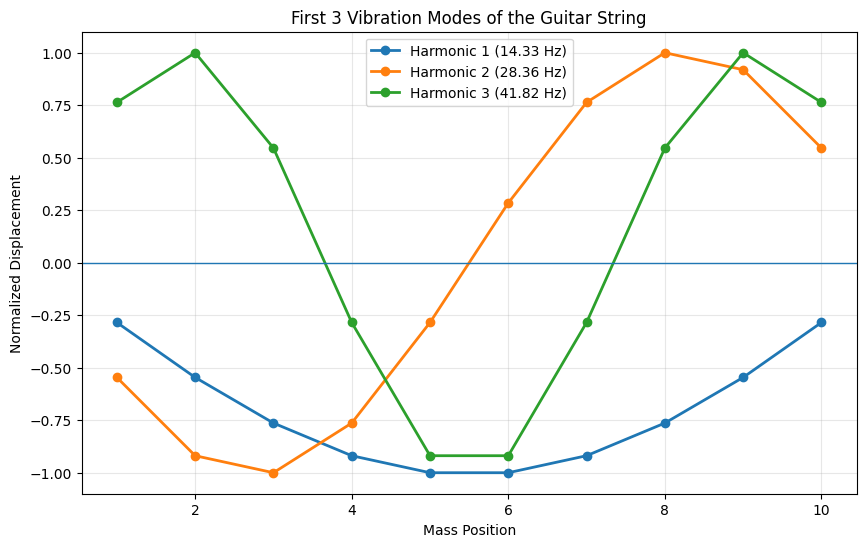

In [ ]:

# =========================
# VIBRATION MODE VISUALIZATION
# =========================

x = np.arange(1, N + 1)

plt.figure(figsize=(10, 6))

for mode in range(3):
    # Normalize each eigenvector
    mode_shape = eigenvectors[:, mode]
    mode_shape = mode_shape / np.max(np.abs(mode_shape))

    plt.plot(
        x,
        mode_shape,
        marker='o',
        linewidth=2,
        label=f"Harmonic {mode+1} ({frequency[mode]:.2f} Hz)"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Mass Position")
plt.ylabel("Normalized Displacement")
plt.title("First 3 Vibration Modes of the Guitar String")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

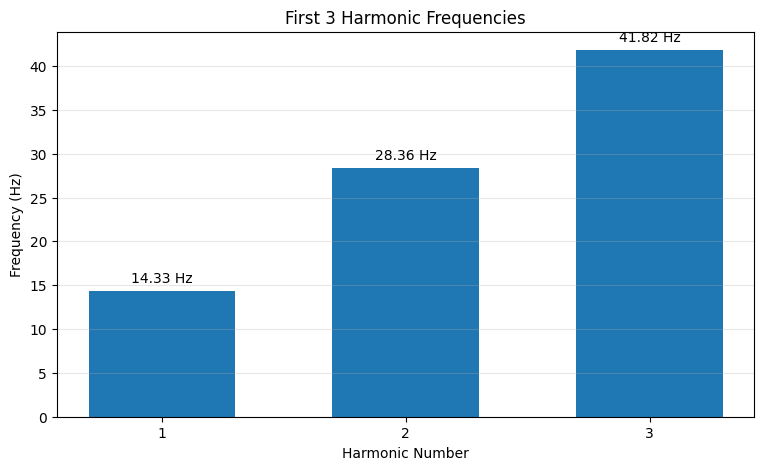

In [ ]:

# =========================
# FREQUENCY CHART
# =========================

plt.figure(figsize=(9, 5))

modes = np.arange(1, 4)

plt.bar(
    modes,
    frequency[:3],
    width=0.6
)

plt.xlabel("Harmonic Number")
plt.ylabel("Frequency (Hz)")
plt.title("First 3 Harmonic Frequencies")

plt.xticks(modes)
plt.grid(axis='y', alpha=0.3)

for i in range(3):
    plt.text(
        i + 1,
        frequency[i] + 1,
        f"{frequency[i]:.2f} Hz",
        ha='center'
    )

plt.show()

In [ ]:

# =========================
# SIMPLE VISUAL STRING MODEL
# =========================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mode_number = 1       # Change to 1, 2, or 3
mode = eigenvectors[:, mode_number - 1]

# Normalize the mode
mode = mode / np.max(np.abs(mode))

fig, ax = plt.subplots(figsize=(10, 5))

line, = ax.plot(
    x,
    np.zeros(N),
    marker='o',
    linewidth=2
)

ax.set_xlim(1, N)
ax.set_ylim(-1.3, 1.3)

ax.set_xlabel("Mass Position")
ax.set_ylabel("Displacement")
ax.set_title(
    f"Animated Harmonic {mode_number} "
    f"({frequency[mode_number-1]:.2f} Hz)"
)

ax.grid(True)

def animate(frame):
    displacement = mode * np.sin(frame * 0.15)
    line.set_ydata(displacement)
    return line,

animation = FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=40,
    blit=True
)

plt.close(fig)

HTML(animation.to_jshtml())

In [ ]:

# =========================
# PROJECT SUMMARY
# =========================

print("MATHEMATICAL SUMMARY")
print("====================")
print()
print("1. The guitar string is modeled using N masses and springs.")
print()
print("2. The stiffness matrix K is tridiagonal:")
print("   Diagonal elements = 2k")
print("   Off-diagonal elements = -k")
print()
print("3. The vibration equation is:")
print("   K v = ω² M v")
print()
print("4. Since M = mI:")
print("   (K/m)v = ω²v")
print()
print("5. Eigenvalues give ω².")
print("6. Square root of eigenvalues gives ω.")
print("7. Frequency is:")
print("   f = ω / (2π)")
print("8. Eigenvectors give the vibration modes.")
print()
print("Therefore, the first three eigenmodes represent")
print("the first three harmonics of the modeled string.")

MATHEMATICAL SUMMARY

1. The guitar string is modeled using N masses and springs.

2. The stiffness matrix K is tridiagonal:
   Diagonal elements = 2k
   Off-diagonal elements = -k

3. The vibration equation is:
   K v = ω² M v

4. Since M = mI:
   (K/m)v = ω²v

5. Eigenvalues give ω².
6. Square root of eigenvalues gives ω.
7. Frequency is:
   f = ω / (2π)
8. Eigenvectors give the vibration modes.

Therefore, the first three eigenmodes represent
the first three harmonics of the modeled string.
